In [6]:
import pandas as pd

df = pd.read_csv(r"C:\Users\hp\Downloads\Titanic_Dataset\tested.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [17]:
df.count()

PassengerId    418
Survived       418
Pclass         418
Name           418
Sex            418
Age            332
SibSp          418
Parch          418
Ticket         418
Fare           417
Cabin           91
Embarked       418
dtype: int64

In [19]:
df.drop(columns="Cabin", inplace=True)
df.head(n=5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [24]:
df['Fare'].fillna(df['Fare'].median(), inplace=True)

In [36]:
df['Age'].fillna(df['Age'].mean().round(1).item())

0      34.5
1      47.0
2      62.0
3      27.0
4      22.0
       ... 
413    30.3
414    39.0
415    38.5
416    30.3
417    30.3
Name: Age, Length: 418, dtype: float64

In [38]:
df.count()

PassengerId    418
Survived       418
Pclass         418
Name           418
Sex            418
Age            418
SibSp          418
Parch          418
Ticket         418
Fare           418
Embarked       418
dtype: int64

In [42]:
features = df.drop(columns=['PassengerId','Survived','SibSp','Parch','Ticket','Embarked', 'Name'])
features

,Pclass,Sex,Age,Fare
0,3,male,34.5,7.8292
1,3,female,47.0,7.0000
2,2,male,62.0,9.6875
3,3,male,27.0,8.6625
4,3,female,22.0,12.2875
...,...,...,...,...
413,3,male,30.3,8.0500
414,1,female,39.0,108.9000
415,3,male,38.5,7.2500
416,3,male,30.3,8.0500


In [43]:
from sklearn.compose import ColumnTransformer

In [44]:
numerical_data = ['Pclass','Age','Fare']
categorical_data = ['Sex']

In [57]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

numerical_pipeline = Pipeline(steps=[
    ('scaler', MinMaxScaler(feature_range=(1, 10)))
])

categorical_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown="ignore"))
])

In [58]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_data),
    ('cat', categorical_pipeline, categorical_data)
])

In [59]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler',
                                                  MinMaxScaler(feature_range=(1,
                                                                              10)))]),
                                 ['Pclass', 'Age', 'Fare']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Sex'])])

In [60]:
from sklearn.linear_model import LogisticRegression

clf = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('Logistic Regression Model', LogisticRegression())
])

In [61]:
clf

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler(feature_range=(1,
                                                                                               10)))]),
                                                  ['Pclass', 'Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex'])])),
                ('Logistic Regression Model', LogisticRegression())])

In [62]:
labels = df['Survived'].values
labels[:10]

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0])

In [63]:
clf.fit(features, labels)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler(feature_range=(1,
                                                                                               10)))]),
                                                  ['Pclass', 'Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex'])])),
                ('Logistic Regression Model', LogisticRegression())])

In [68]:
features[30:]

,Pclass,Sex,Age,Fare
30,2,male,50.0,26.0000
31,2,male,24.0,31.5000
32,3,female,33.0,20.5750
33,3,female,30.3,23.4500
34,1,male,30.0,57.7500
...,...,...,...,...
413,3,male,30.3,8.0500
414,1,female,39.0,108.9000
415,3,male,38.5,7.2500
416,3,male,30.3,8.0500


In [69]:
labels[30:]

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,

In [70]:
pred = clf.predict(features[30:])

In [73]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(pred, labels[30:])
accuracy

1.0

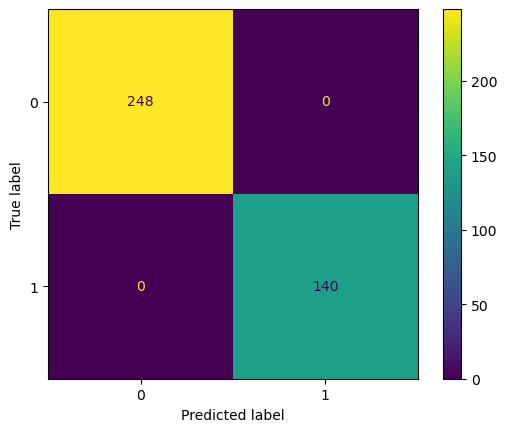

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(pred, labels[30:])
ConfusionMatrixDisplay(cm).plot()
plt.show()